# Week 3, Day 1 — Build a World, Then Learn to Solve It

Before any of this touches the stock market, we need the actual vocabulary of
reinforcement learning — and the best way to get it isn't to read definitions,
it's to **build the smallest possible world yourself**, then watch an agent
learn to solve it from nothing but trial and error.

**Today you will:**
1. Build a tiny grid-world **from scratch** — no library, no black box. Every
   rule exists because you wrote it.
2. Learn the four pieces every reinforcement learning problem is made of:
   **state, action, reward, transition.**
3. Build a Q-table and watch it learn the optimal path, from pure experience.
4. See exactly why this method has a hard ceiling — which is precisely what
   tomorrow's notebook exists to fix.

## 1. The vocabulary, before any code

Every reinforcement learning problem — a maze, a video game, a trading
strategy — is described using the same four ingredients. This formal
structure is called a **Markov Decision Process (MDP)**.

- **State ($s$)** — a complete description of "where things stand right now."
  In a maze: which cell you're in. Nothing about the past matters beyond what
  the current state already captures — this is called the **Markov
  property**: the future only depends on the present state, not on the path
  you took to get here.
- **Action ($a$)** — a choice the agent is allowed to make. In a maze: up,
  down, left, right.
- **Reward ($r$)** — a number the environment hands back after each action,
  telling the agent how good that action was. Reaching the goal: a big
  positive number. Falling in a trap: a big negative number. Just moving:
  maybe a small negative number, so the agent prefers *efficient* paths, not
  just *eventual* ones.
- **Transition** — the rule that decides the next state, given the current
  state and the action taken. In a deterministic grid: move up, and you end
  up in the cell above (unless there's a wall).

**The agent's entire job:** choose actions that maximize *total future
reward*, not just the next reward. A path that takes one extra step but
avoids a trap is better than a short path through danger — the agent has to
learn to see that far ahead, from experience alone.
- **Policy ($\pi$)** — the agent's actual rule for choosing an action, given a
  state. Everything above (state, action, reward, transition) describes the
  *world*. The policy is the agent's own brain — the thing that's actually
  being learned. Later in this notebook, once the Q-table is trained, "look
  up the current state's row, take the best column" **is** the policy — a
  lookup table, in its simplest possible form.

## 2. Build the world

A 4×5 grid. One start cell, one goal, one trap. You will define the state
representation, the transition rule, and the reward rule yourself — nothing
here comes from a library.

**Design decisions, stated explicitly:**
- **State** = a single integer, `row * n_cols + col`. A 4×5 grid has 20 cells,
  so states are integers 0–19. This is the simplest possible state
  representation for something spatial.
- **Actions** = 0 (up), 1 (down), 2 (left), 3 (right).
- **Reward** = `+10` for reaching the goal, `-10` for the trap, `-1` for every
  other step (so the agent is pushed toward *short* paths, not just *any*
  path that eventually works).
- Walking into a wall is not a special case — it simply doesn't move you.
  Same `-1` step penalty applies, so the agent naturally learns to stop doing
  it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N_ROWS, N_COLS = 4, 5
N_STATES = N_ROWS * N_COLS
N_ACTIONS = 4   # 0=up, 1=down, 2=left, 3=right

START = (0, 0)
GOAL = (3, 4)
TRAP = (2, 2)

def to_state(row, col):
    return row * N_COLS + col

def to_rowcol(state):
    return divmod(state, N_COLS)

GOAL_STATE = to_state(*GOAL)
TRAP_STATE = to_state(*TRAP)
START_STATE = to_state(*START)

print(f'grid: {N_ROWS} rows x {N_COLS} cols = {N_STATES} states')
print(f'start state: {START_STATE}  goal state: {GOAL_STATE}  trap state: {TRAP_STATE}')

grid: 4 rows x 5 cols = 20 states
start state: 0  goal state: 19  trap state: 12


### The transition function — build it yourself

**In:** current `state` (an integer), `action` (0–3).
**Out:** the resulting `next_state`.
**Rule:** convert to (row, col), apply the move, clip to stay inside the
grid (walking into a wall = no movement), convert back to a state integer.
**Done when:** the check below passes.

In [2]:
def take_action(state, action):
    row, col = to_rowcol(state)

    # ---8<--- solution
    if action == 0:   row -= 1   # up
    elif action == 1: row += 1   # down
    elif action == 2: col -= 1   # left
    elif action == 3: col += 1   # right

    row = np.clip(row, 0, N_ROWS - 1)
    col = np.clip(col, 0, N_COLS - 1)
    # ---8<--- end

    return to_state(row, col)


# check: moving up from the top row should not move you at all
assert take_action(to_state(0, 2), 0) == to_state(0, 2), 'walking into the top wall should not move you'
# check: moving right from a normal cell should move you right
assert take_action(to_state(1, 1), 3) == to_state(1, 2), 'moving right should increase column by 1'
# check: moving down from the bottom row should not move you at all
assert take_action(to_state(N_ROWS-1, 2), 1) == to_state(N_ROWS-1, 2), 'walking into the bottom wall should not move you'
print('take_action correct ✓')

take_action correct ✓


### The reward function — build it yourself

**In:** the `state` the agent lands in after acting.
**Out:** the reward for landing there.
**Rule:** `+10` at the goal, `-10` at the trap, `-1` everywhere else.
**Done when:** the check below passes.

In [3]:
def get_reward(state):
    # ---8<--- solution
    if state == GOAL_STATE:
        return 10.0
    elif state == TRAP_STATE:
        return -10.0
    else:
        return -1.0
    # ---8<--- end


assert get_reward(GOAL_STATE) == 10.0
assert get_reward(TRAP_STATE) == -10.0
assert get_reward(START_STATE) == -1.0
print('get_reward correct ✓')

get_reward correct ✓


### Wrap it as a real environment

Same `reset()` / `step()` shape you'll see in every environment for the rest
of this program — including the real market simulator next week. An episode
ends when you reach the goal, fall in the trap, or run out of steps.

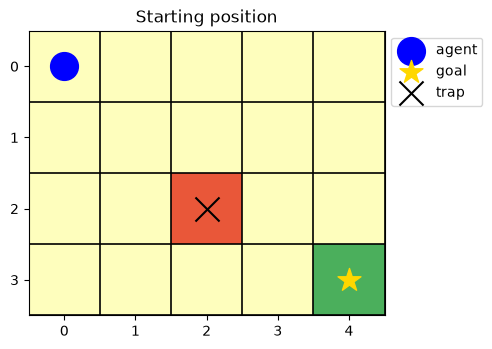

In [4]:
class GridWorld:
    def __init__(self, max_steps=50):
        self.max_steps = max_steps

    def reset(self):
        self.state = START_STATE
        self.steps = 0
        return self.state

    def step(self, action):
        self.state = take_action(self.state, action)
        self.steps += 1
        reward = get_reward(self.state)
        done = (self.state == GOAL_STATE) or (self.state == TRAP_STATE) or (self.steps >= self.max_steps)
        return self.state, reward, done


def render(state, title=''):
    grid = np.zeros((N_ROWS, N_COLS))
    grid[GOAL] = 2
    grid[TRAP] = -2
    r, c = to_rowcol(state)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(grid, cmap='RdYlGn', vmin=-3, vmax=3)
    ax.scatter(c, r, s=400, color='blue', marker='o', zorder=5, label='agent')
    ax.scatter(GOAL[1], GOAL[0], s=300, color='gold', marker='*', zorder=4, label='goal')
    ax.scatter(TRAP[1], TRAP[0], s=300, color='black', marker='x', zorder=4, label='trap')
    ax.set_xticks(range(N_COLS)); ax.set_yticks(range(N_ROWS))
    # gridlines between cells, not through their centers -- offset by half a cell
    ax.set_xticks(np.arange(-0.5, N_COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, N_ROWS, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=1.2)
    ax.tick_params(which='minor', length=0)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

env = GridWorld()
s = env.reset()
render(s, 'Starting position')

## 3. Q-learning — learning values from experience alone

A **Q-table** stores one number, $Q(s, a)$, for every (state, action) pair —
"how good is it to take this action, from this state, considering everything
that might happen afterward?" With 20 states and 4 actions, that's an 80-entry
table. Small enough to print in full.

**The update rule (the Bellman equation), in plain terms:** after taking
action $a$ from state $s$, landing in $s'$ and receiving reward $r$, nudge
your estimate of $Q(s,a)$ toward "the reward you just got, plus the best you
could still do from here on":

$$Q(s,a) \leftarrow Q(s,a) + \alpha \Big[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \Big]$$

- $\alpha$ (learning rate) — how much to trust each new experience over the old estimate.
- $\gamma$ (discount factor) — how much future reward matters relative to
  immediate reward. Close to 1: "plan far ahead." Close to 0: "only care about
  right now."
- $\max_{a'} Q(s', a')$ — the best the agent thinks it can do from the *next*
  state onward. This is what lets reward propagate backward through the
  table over time, from the goal outward to every state that can reach it.

### Build the update rule yourself

**In:** the table `Q`, `state`, `action`, `reward`, `next_state`, `alpha`, `gamma`.
**Out:** nothing — update `Q` in place.
**Done when:** the check below passes.

In [5]:
def q_update(Q, state, action, reward, next_state, alpha=0.1, gamma=0.95):
    # ---8<--- solution
    best_next = np.max(Q[next_state])
    td_target = reward + gamma * best_next
    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error
    # ---8<--- end


# check: a single update should move Q(s,a) TOWARD the target, not overshoot it
Q_test = np.zeros((N_STATES, N_ACTIONS))
q_update(Q_test, state=0, action=1, reward=10.0, next_state=GOAL_STATE, alpha=0.1, gamma=0.95)
assert 0 < Q_test[0, 1] < 10.0, 'one update with alpha=0.1 should move partway toward the target, not all the way'
print('q_update correct ✓  (Q(0,1) moved to', round(Q_test[0,1], 3), ')')

q_update correct ✓  (Q(0,1) moved to 1.0 )


### Build epsilon-greedy exploration yourself

If the agent always picks the action it currently *thinks* is best, it can
get stuck on a mediocre path it found early and never discover a better one.
**Epsilon-greedy** fixes this: with probability `epsilon`, take a completely
random action instead (explore); otherwise, take the best known action
(exploit).

**In:** `Q`, `state`, `epsilon`.
**Out:** an action (integer 0–3).
**Done when:** the check below passes.

In [6]:
def epsilon_greedy(Q, state, epsilon):
    # ---8<--- solution
    if np.random.random() < epsilon:
        return np.random.randint(N_ACTIONS)
    else:
        return int(np.argmax(Q[state]))
    # ---8<--- end


# check: epsilon=0 should ALWAYS pick the known-best action
Q_test = np.zeros((N_STATES, N_ACTIONS)); Q_test[5] = [1, 5, 2, 0]
actions = [epsilon_greedy(Q_test, 5, epsilon=0.0) for _ in range(20)]
assert all(a == 1 for a in actions), 'epsilon=0 should always be greedy'

# check: epsilon=1 should explore -- not always pick the same action
np.random.seed(0)
actions = [epsilon_greedy(Q_test, 5, epsilon=1.0) for _ in range(50)]
assert len(set(actions)) > 1, 'epsilon=1 should explore randomly, not always pick one action'
print('epsilon_greedy correct ✓')

epsilon_greedy correct ✓


## 4. Train it — watch the table learn from nothing

Start with every entry at zero — the agent knows *nothing* about the world.
Run thousands of episodes. Each one: start at the beginning, act, observe the
result, update the table, repeat until the episode ends. `epsilon` decays
over training — explore heavily at first, exploit more as the table becomes
trustworthy.

In [7]:
np.random.seed(0)
Q = np.zeros((N_STATES, N_ACTIONS))

N_EPISODES = 3000
ALPHA, GAMMA = 0.1, 0.95
epsilon = 1.0
EPSILON_DECAY = 0.999
EPSILON_MIN = 0.05

episode_rewards = []

for ep in range(N_EPISODES):
    state = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = epsilon_greedy(Q, state, epsilon)
        next_state, reward, done = env.step(action)
        q_update(Q, state, action, reward, next_state, ALPHA, GAMMA)
        state = next_state
        total_reward += reward
    episode_rewards.append(total_reward)
    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

print(f'training done. final epsilon: {epsilon:.3f}')
print(f'average reward, first 100 episodes:  {np.mean(episode_rewards[:100]):.2f}')
print(f'average reward, last 100 episodes:   {np.mean(episode_rewards[-100:]):.2f}')

training done. final epsilon: 0.050
average reward, first 100 episodes:  -25.44
average reward, last 100 episodes:   3.70


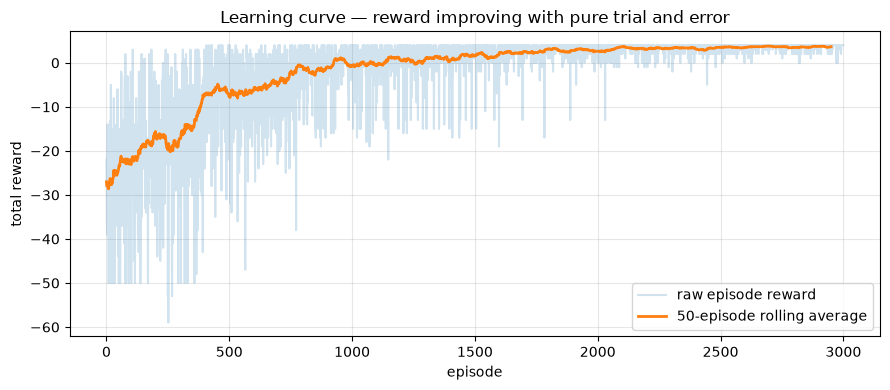

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
window = 50
smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
ax.plot(episode_rewards, alpha=0.2, label='raw episode reward')
ax.plot(smoothed, linewidth=2, label=f'{window}-episode rolling average')
ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel('episode'); ax.set_ylabel('total reward')
ax.set_title('Learning curve — reward improving with pure trial and error')
plt.tight_layout(); plt.show()

**What you should see:** a noisy, low start (mostly random wandering, often
hitting the trap or running out of steps), climbing steadily as the table
fills in, then leveling off near the best achievable score. Nothing here was
told the correct path — every number in that table was built purely from
20,000+ trial-and-error experiences.

## 5. See what it actually learned

Two views: the table itself (just numbers), and the *policy* — the single
best action at every state, which is much easier to actually read.

In [9]:
print('Q-table (rounded), one row per state:')
print(Q.round(1))

Q-table (rounded), one row per state:
[[  1.    2.1   1.    2.1]
 [  2.1   3.2   1.    3.2]
 [  3.2   4.4   2.1   4.4]
 [  4.4   5.7   3.2   5.7]
 [  5.7   7.1   4.4   5.7]
 [  0.9   2.3   2.    3.2]
 [  2.1   3.9   2.1   4.4]
 [  3.2 -10.    3.2   5.7]
 [  4.4   7.1   4.4   7.1]
 [  5.7   8.5   5.7   7.1]
 [  1.    1.1   0.    4. ]
 [  3.    5.6   1.4 -10. ]
 [  0.    0.    0.    0. ]
 [  5.7   8.5 -10.    8.5]
 [  7.1  10.    7.1   8.5]
 [ -0.4  -0.3   0.1   4.5]
 [  2.2   3.7   1.5   7. ]
 [ -9.8   5.5   3.5   8.5]
 [  6.3   7.1   5.9  10. ]
 [  0.    0.    0.    0. ]]


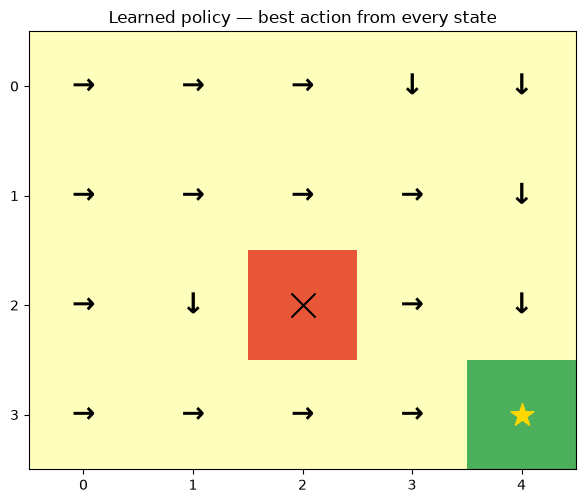

In [10]:
ARROWS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

fig, ax = plt.subplots(figsize=(6, 5))
grid = np.zeros((N_ROWS, N_COLS))
grid[GOAL] = 2
grid[TRAP] = -2
ax.imshow(grid, cmap='RdYlGn', vmin=-3, vmax=3)

for s in range(N_STATES):
    if s in (GOAL_STATE, TRAP_STATE):
        continue
    r, c = to_rowcol(s)
    best_a = int(np.argmax(Q[s]))
    ax.text(c, r, ARROWS[best_a], ha='center', va='center', fontsize=20, fontweight='bold')

ax.scatter(GOAL[1], GOAL[0], s=300, color='gold', marker='*', zorder=4)
ax.scatter(TRAP[1], TRAP[0], s=300, color='black', marker='x', zorder=4)
ax.set_xticks(range(N_COLS)); ax.set_yticks(range(N_ROWS))
ax.set_title('Learned policy — best action from every state')
plt.tight_layout(); plt.show()

**Read this like a map.** Every arrow should point roughly toward the goal,
and — this is the interesting part — arrows near the trap should visibly
route *around* it, not through it, even though going through might look like
a shorter path. The agent learned that the `-10` penalty isn't worth the
shortcut, purely from experience, without ever being told where the trap
was in advance.

## 6. Where this breaks — and why it has to

This worked because the world was small enough to **enumerate completely** —
20 states, 4 actions, 80 numbers, every single one directly reachable and
updatable.

**Ask yourself:** what would happen to this exact method if the state were
not "which of 20 cells am I in," but a stock's price, its momentum, its
volatility — real numbers, not one of a small fixed set? There is no way to
build a row in a table for "price = 47.283619..." — the number of possible
states is not just large, it is **infinite**.

A Q-*table* cannot survive that. A Q-*table* needs one row per state. What
you need instead is something that can take a continuous state as input and
still produce a sensible answer — which is exactly what a neural network
does.

**Tomorrow:** the table gets replaced with a network, on an environment
where the state genuinely cannot be counted — and, deliberately, you will
not build that environment yourself. You'll learn to *read* one instead,
because that is exactly the skill you'll need for the real market
environment waiting at the end of this week.